# Credit Risk EDA — Lending Club 2007–2018
Exploratory analysis of 1.35M **completed** loans (Fully Paid / Charged Off) from the DuckDB warehouse built by `sql/01–03`.

Everything here reads from tables the SQL pipeline produced — the notebook contains no cleaning logic of its own, so every number matches the dashboard and the risk memo.

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.options.display.float_format = "{:.3f}".format
sns.set_theme(style="whitegrid")
con = duckdb.connect("../warehouse.duckdb", read_only=True)

## 1. The book at a glance
Default rate is monotonic in grade — the originator's own risk ranking works. The interesting question is what it *costs* (see LGD below) and where it hides pockets worse than the grade average.

In [2]:
con.execute("""
SELECT grade,
       COUNT(*)                          AS n_loans,
       ROUND(AVG(is_default) * 100, 1)   AS default_pct,
       ROUND(AVG(int_rate), 1)           AS avg_rate_pct,
       ROUND(AVG(fico), 0)               AS avg_fico,
       ROUND(AVG(dti), 1)                AS avg_dti,
       ROUND(SUM(loan_amnt) / 1e9, 2)    AS disbursed_bn_usd
FROM features.loan_features
GROUP BY grade ORDER BY grade
""").fetchdf()

,grade,n_loans,default_pct,avg_rate_pct,avg_fico,avg_dti,disbursed_bn_usd
0,A,235184,6.000,7.100,730.000,15.600,3.270
1,B,393095,13.400,10.700,699.000,17.400,5.200
2,C,382315,22.400,14.000,690.000,18.900,5.420
3,D,201644,30.400,17.700,685.000,20.200,3.070
4,E,94186,38.400,21.100,684.000,20.800,1.650
5,F,32305,45.100,24.900,682.000,20.900,0.610
6,G,9326,49.700,27.500,680.000,21.500,0.190


## 2. Do the underwriting variables separate good from bad?
Interest rate is the strongest single separator — unsurprising, since it *embeds* the underwriter's risk view. FICO separates, but far less than people expect on an already-filtered book (LC declined <660 upfront, so we only see the survivors).

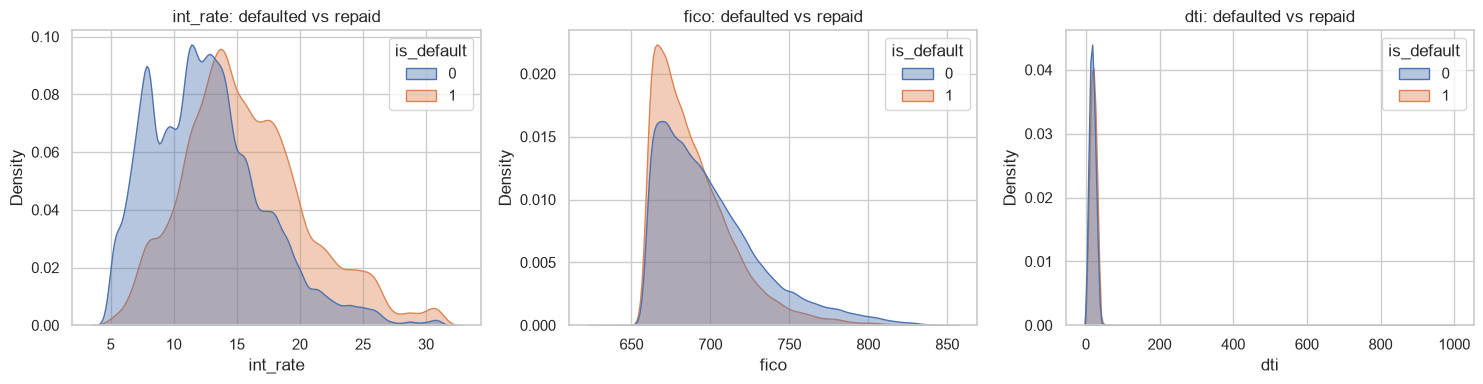

In [3]:
sample = con.execute("""
SELECT is_default, int_rate, fico, dti, loan_to_income
FROM features.loan_features USING SAMPLE 150000
""").fetchdf()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["int_rate", "fico", "dti"]):
    sns.kdeplot(data=sample, x=col, hue="is_default",
                common_norm=False, fill=True, alpha=0.4, ax=ax)
    ax.set_title(f"{col}: defaulted vs repaid")
plt.tight_layout()

## 3. Segment heatmap — where risk concentrates
Grade dominates, but *within* the risky grades, income decile still spreads default rates by 5–8 percentage points. The worst cells (grade G × low income deciles on debt-consolidation loans) default at 52–58% — **2.6–2.9× the book average of 20%**.

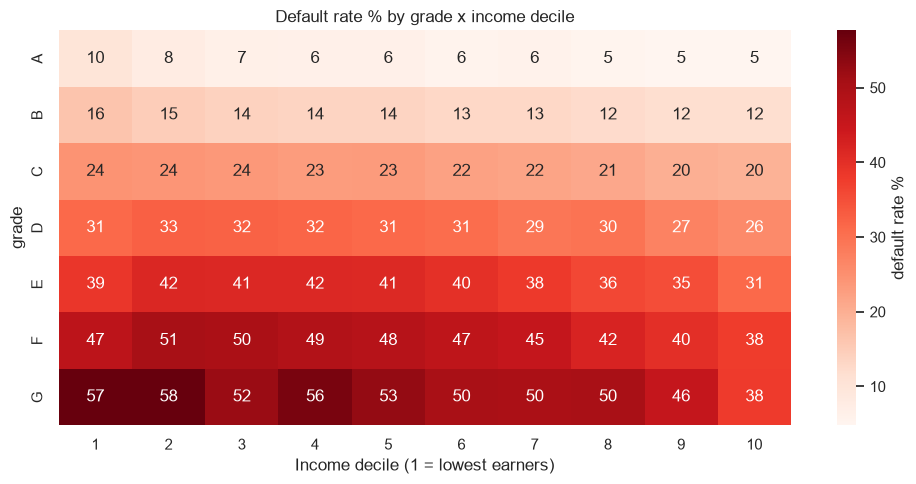

In [4]:
seg = con.execute("""
SELECT grade, income_decile,
       SUM(n_loans * default_rate) / SUM(n_loans) AS default_rate
FROM features.segment_risk
GROUP BY grade, income_decile
""").fetchdf()
pivot = seg.pivot(index="grade", columns="income_decile", values="default_rate")

plt.figure(figsize=(10, 5))
sns.heatmap(pivot * 100, annot=True, fmt=".0f", cmap="Reds",
            cbar_kws={"label": "default rate %"})
plt.title("Default rate % by grade x income decile")
plt.xlabel("Income decile (1 = lowest earners)")
plt.tight_layout()

## 4. Vintage curves — underwriting quality over time
Cumulative default rate by months-on-book, per issue year. Post-crisis vintages (2009–2011) were the cleanest; quality deteriorates monotonically from 2012 to 2016 as origination volume scaled. This is the chart a risk team would use to argue the book is drifting.

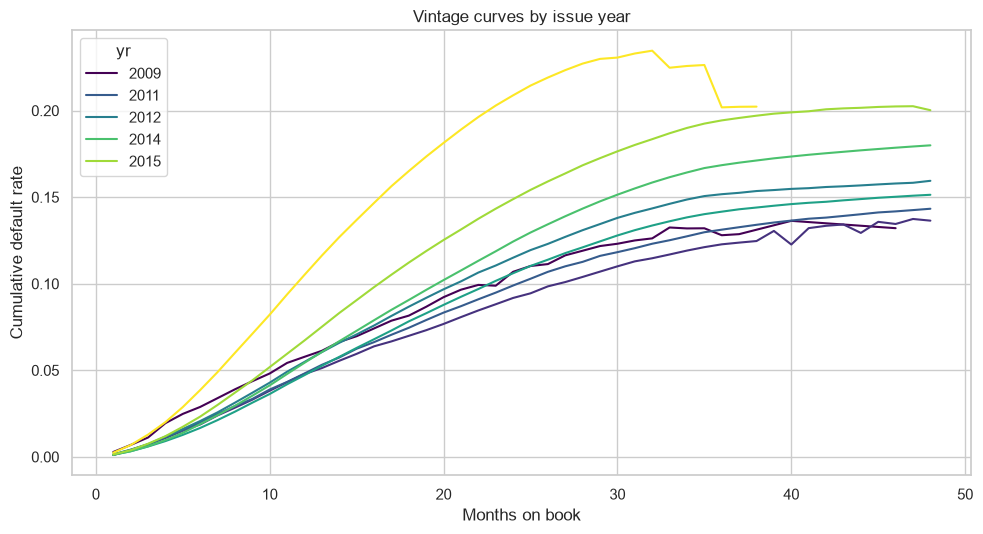

In [5]:
vc = con.execute("""
SELECT EXTRACT(year FROM vintage_quarter)::INT AS yr, mob,
       AVG(cum_default_rate) AS cum_dr
FROM risk.vintage_curves
WHERE yr BETWEEN 2009 AND 2016 AND mob <= 48
GROUP BY yr, mob ORDER BY yr, mob
""").fetchdf()

plt.figure(figsize=(10, 5.5))
sns.lineplot(data=vc, x="mob", y="cum_dr", hue="yr", palette="viridis")
plt.ylabel("Cumulative default rate")
plt.xlabel("Months on book")
plt.title("Vintage curves by issue year")
plt.tight_layout()

## 5. The verification-status inversion (selection effect)
Income-**verified** loans default *more* than unverified ones. Verification is not protective — it was **triggered by** applications that already looked risky. Reading operational flags as causal is the classic analytics trap; any policy proposal built on "verify more loans" from this correlation would be backwards.

In [6]:
con.execute("""
SELECT verification_status,
       COUNT(*)                        AS n,
       ROUND(AVG(is_default)*100, 1)   AS default_pct,
       ROUND(AVG(annual_inc), 0)       AS avg_income,
       ROUND(AVG(dti), 1)              AS avg_dti,
       ROUND(AVG(int_rate), 1)         AS avg_rate
FROM features.loan_features
GROUP BY 1 ORDER BY default_pct DESC
""").fetchdf()

,verification_status,n,default_pct,avg_income,avg_dti,avg_rate
0,Verified,418963,23.900,77103.000,19.800,14.800
1,Source Verified,521563,21.000,80570.000,17.500,13.300
2,Not Verified,407529,14.700,69803.000,17.700,11.600


## 6. Loss economics — PD vs LGD
PD spans 6% → 50% across grades while LGD is flat (~37–40%): for unsecured lending, *who* defaults matters enormously, *how much you lose when they do* barely varies. Expected-loss management is therefore PD management.

In [7]:
gl = con.execute("SELECT * FROM risk.grade_loss ORDER BY grade").fetchdf()
gl[["grade", "n_loans", "pd_observed", "lgd", "loss_rate"]]

,grade,n_loans,pd_observed,lgd,loss_rate
0,A,235184,0.060,0.396,0.024
1,B,393095,0.134,0.392,0.054
2,C,382315,0.224,0.399,0.093
3,D,201644,0.304,0.391,0.125
4,E,94186,0.384,0.372,0.147
5,F,32305,0.451,0.369,0.171
6,G,9326,0.497,0.404,0.200


## 7. The cutoff economics (test set, out-of-time)
From `reports/cutoff_table.csv` (produced by `src/business_metrics.py` using the champion model's calibrated PDs). The recommended operating point — decline PD ≥ 25% — keeps 71% of approvals and cuts the approved book's default rate from 21.7% to 15.1%.

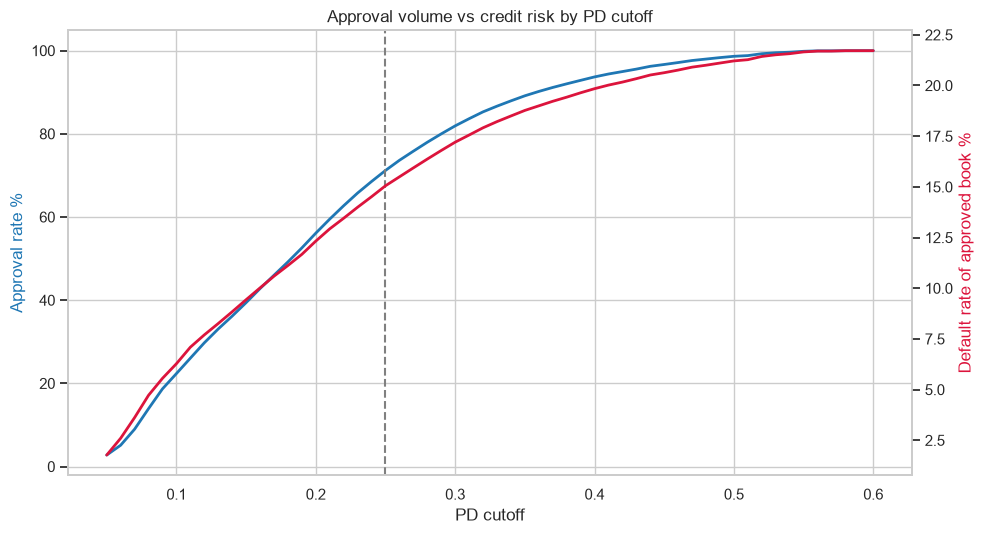

In [8]:
ct = pd.read_csv("../reports/cutoff_table.csv")
fig, ax1 = plt.subplots(figsize=(10, 5.5))
ax1.plot(ct["pd_cutoff"], ct["approval_rate"] * 100, lw=2, color="tab:blue")
ax1.set_ylabel("Approval rate %", color="tab:blue")
ax1.set_xlabel("PD cutoff")
ax1.axvline(0.25, color="gray", ls="--")
ax2 = ax1.twinx()
ax2.plot(ct["pd_cutoff"], ct["default_rate"] * 100, lw=2, color="crimson")
ax2.set_ylabel("Default rate of approved book %", color="crimson")
ax2.grid(False)
plt.title("Approval volume vs credit risk by PD cutoff")
plt.tight_layout()

## Takeaways
1. **Grade is the backbone** of risk ranking, but segment cuts expose pockets at 2.9× book default within it.
2. **Vintages deteriorated 2012→2016** — growth traded against quality.
3. **LGD is flat**, so expected loss is driven almost entirely by PD → invest in selection, not recovery.
4. **Verification status is a selection artifact**, not a causal lever.
5. The cutoff decision is an economics question; the full recommendation lives in [`docs/risk_memo.md`](../docs/risk_memo.md).

In [9]:
con.close()